In [ ]:
#Task 1: Exploratory Data Analysis (EDA)

In [ ]:
#Missing Value
# df.isnull()
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
#for numeircal data :- max, min, avg, mean ,0, ffill, bfill, median
#for categorical data column - mode

In [ ]:
#There is no missing values, we don't need to fix the missing values

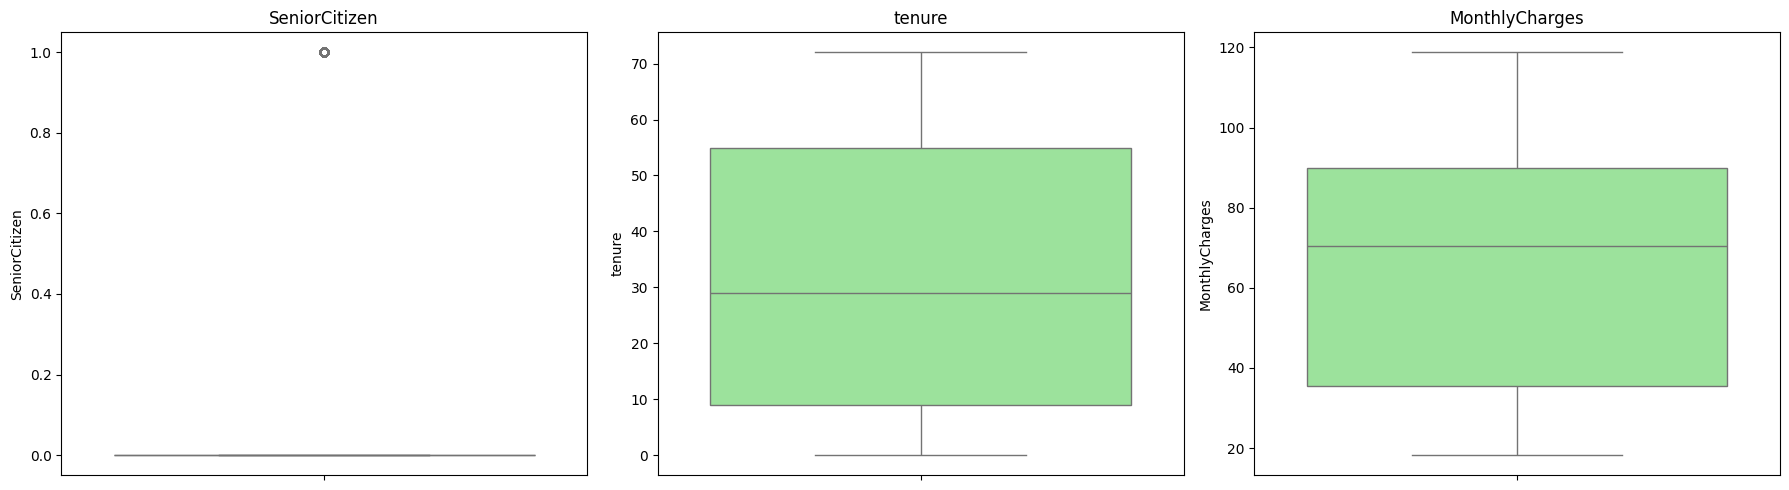

In [ ]:
#detecting and handling outliers
numerical_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges']
plt.figure(figsize=(18,5))


for i, col in enumerate(numerical_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(df[col], color = 'lightgreen')
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
#To verify the outlier removal, let's re-plot the box plots and check the number of outliers again.

In [ ]:
df_cleaned = df.copy()

for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers for the current column
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]

print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape after outlier removal: {df_cleaned.shape}")

df = df_cleaned.copy()

Original DataFrame shape: (7043, 21)
Cleaned DataFrame shape after outlier removal: (5901, 21)


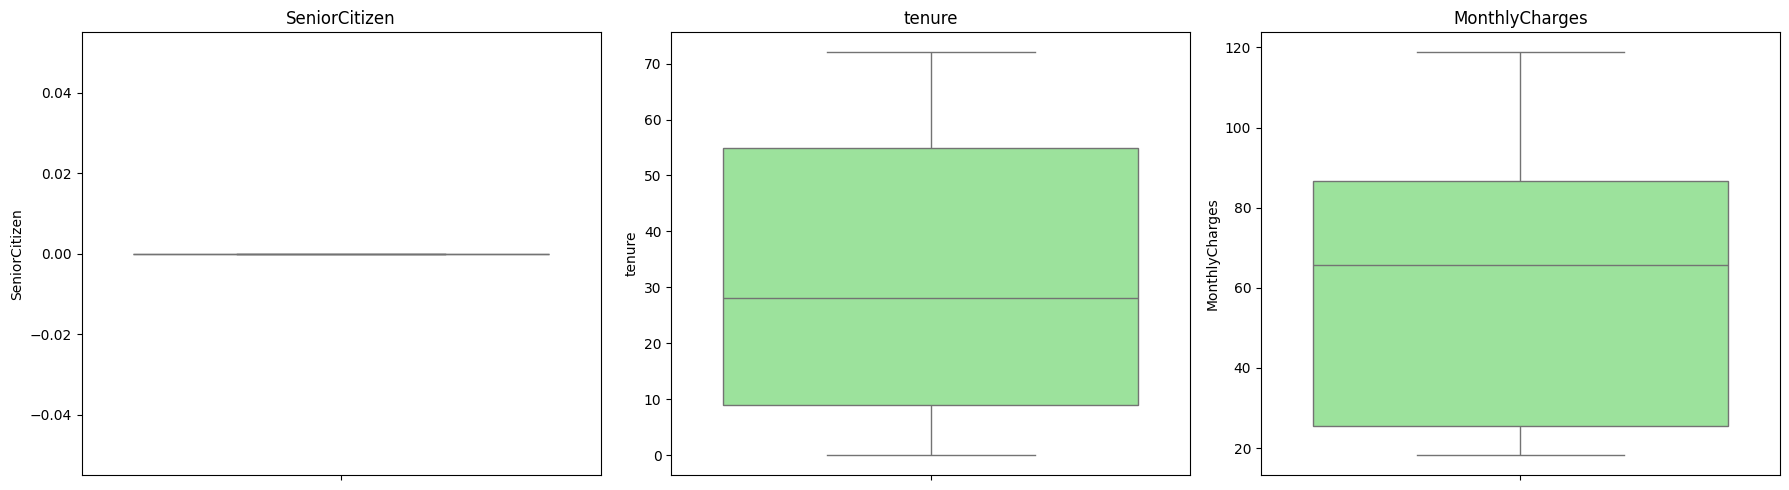

In [ ]:
numerical_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges']
plt.figure(figsize=(18,5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(df[col], color = 'lightgreen')
    plt.title(col)
plt.tight_layout()
plt.show()

Distribution of Churn:
 Churn
No     4508
Yes    1393
Name: count, dtype: int64


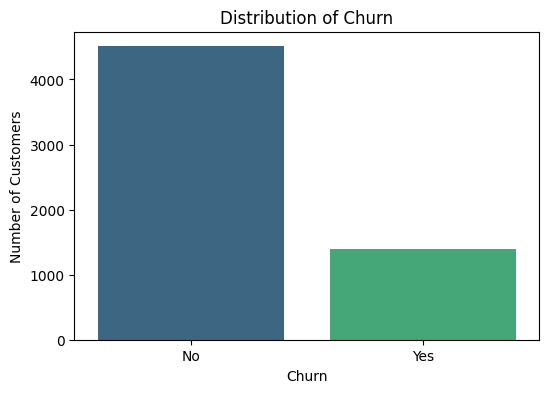

In [ ]:
#churn imbalance in Churn column(distribution plot)
churn_distribution = df['Churn'].value_counts()
print("Distribution of Churn:\n", churn_distribution)

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis', hue='Churn', legend=False)
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

Histograms for numerical features:


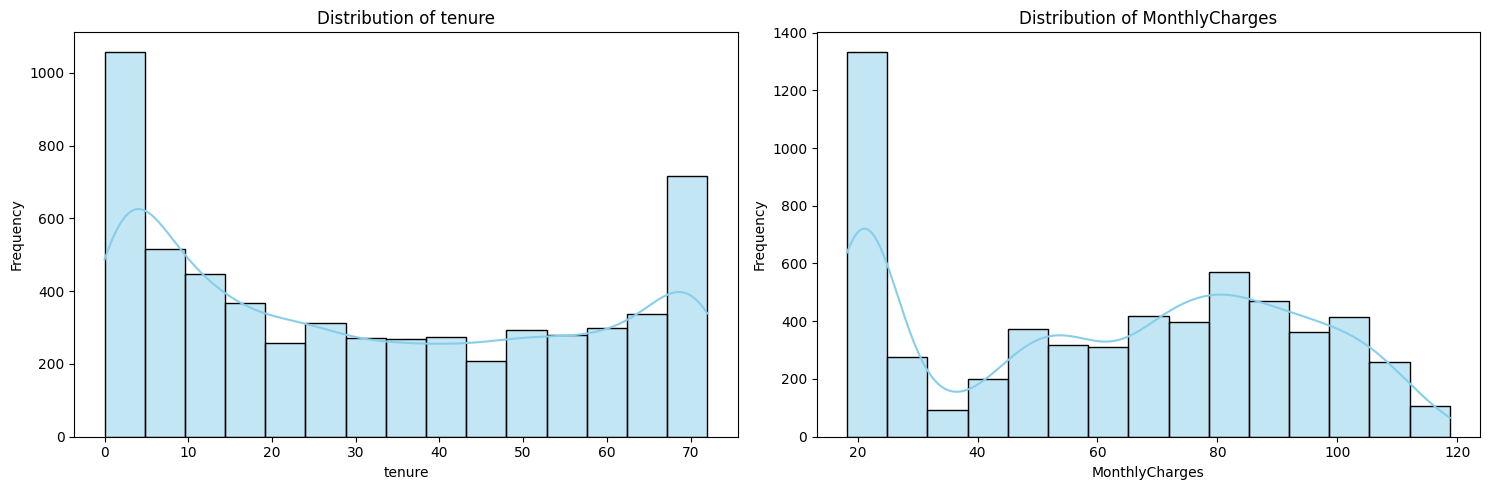


Box plots for numerical features:


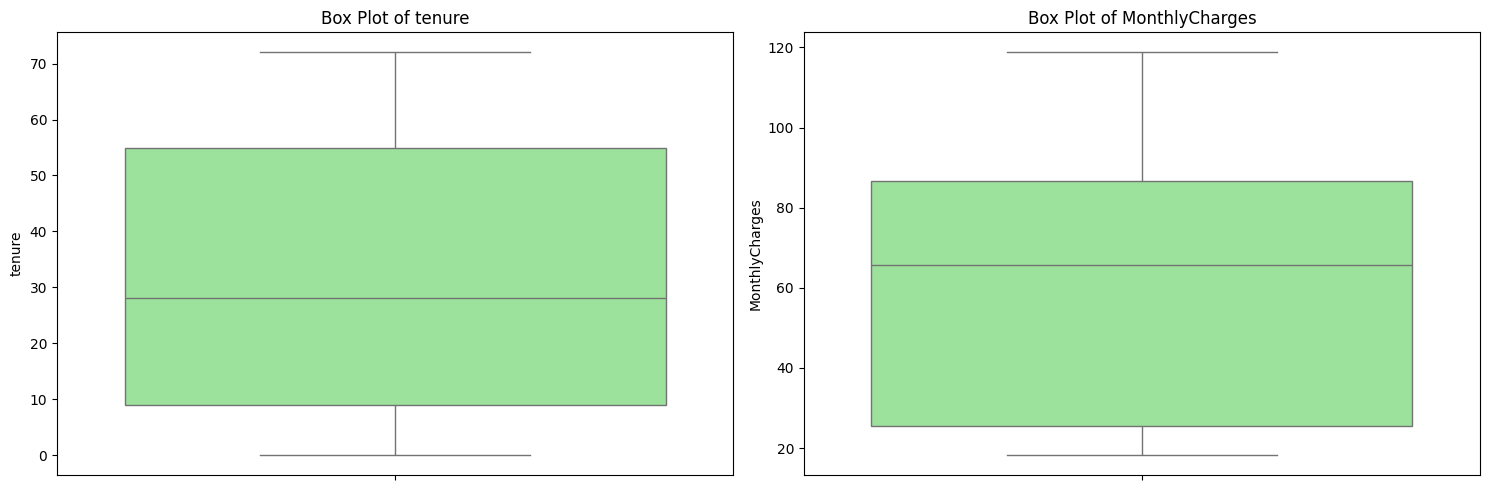

In [ ]:
#Feature distribution analysis(histograms, boxplots)
# Exclude 'SeniorCitizen' from histogram as it's binary and from boxplot due to previous NaN issue after outlier removal.
numerical_cols = ['tenure', 'MonthlyCharges']

print("Histograms for numerical features:")
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 2, i + 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("\nBox plots for numerical features:")
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

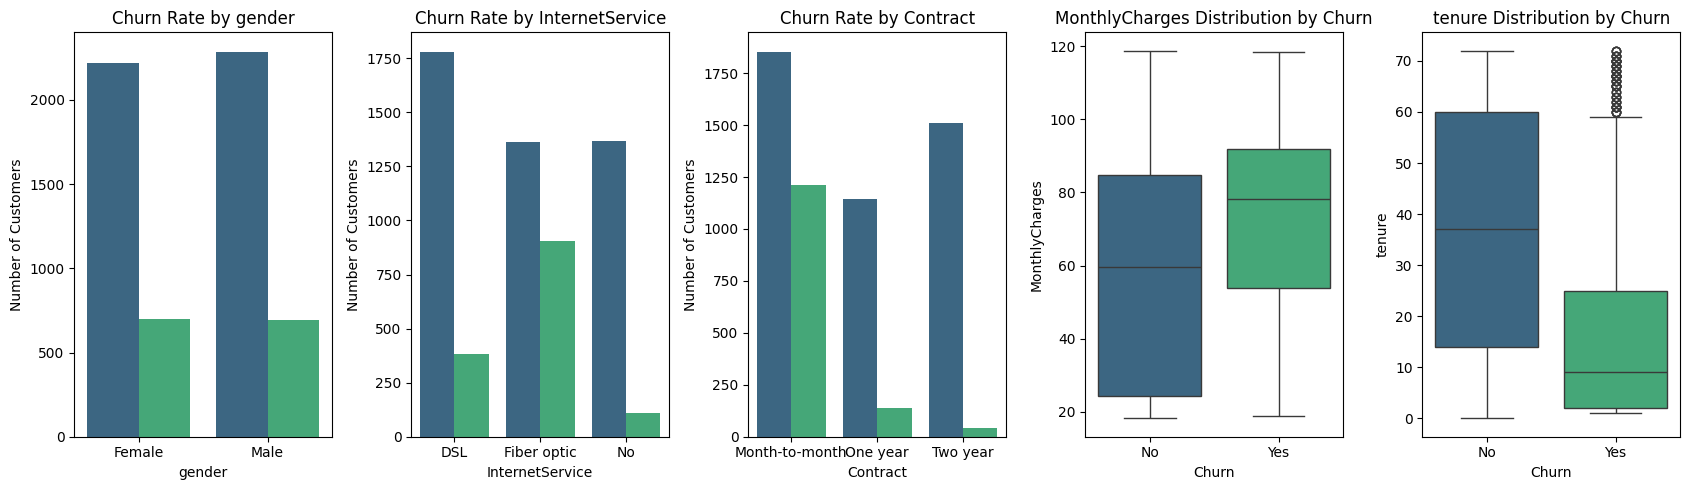

In [ ]:
#Features relates to churn
import matplotlib.pyplot as plt
import seaborn as sns

# List of features to analyze against Churn
features_for_bivariate = ['gender', 'InternetService', 'Contract', 'MonthlyCharges', 'tenure']

# Set up the figure and axes for plotting
plt.figure(figsize=(17, 5))

for i, col in enumerate(features_for_bivariate):
    plt.subplot(1, 5, i + 1) # Adjust subplot grid based on number of features
    if df[col].dtype == 'object': # Categorical features (excluding 'SeniorCitizen' from here as it's already handled as numerical type for outliers and often treated as binary category)
        sns.countplot(x=col, hue='Churn', data=df, palette='viridis', legend=False)
        plt.title(f'Churn Rate by {col}')
        plt.xlabel(col)
        plt.ylabel('Number of Customers')
    else: # Numerical features, including 'SeniorCitizen' if it were here
        sns.boxplot(x='Churn', y=col, data=df, palette='viridis', hue='Churn', legend=False)
        plt.title(f'{col} Distribution by Churn')
        plt.xlabel('Churn')
        plt.ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
#Documents for business insights from EDA
"""
1.Contract Type is a Major Churn Driver: Customers on 'Month-to-month' contracts show a significantly higher churn rate compared to those on 'One year' or 'Two year' contracts. This suggests that encouraging customers to opt for longer-term contracts, possibly through discounts or benefits, could be an effective retention strategy.
2.Fiber Optic Internet Users are Prone to Churn: Customers subscribing to 'Fiber optic' internet service exhibit a higher churn rate. This could indicate potential issues with the service quality, reliability, or perceived value of the fiber optic offering, warranting further investigation into customer satisfaction for this specific service.
3.Newer Customers with Higher Monthly Charges are at Risk: Our analysis indicates that customers with shorter 'tenure' (newer customers) and those with higher 'MonthlyCharges' tend to churn more frequently. This highlights the importance of strong onboarding programs for new customers and potentially reviewing pricing tiers or offering value-added services for customers with higher monthly bills to prevent early departures.
"""

"\n1.Contract Type is a Major Churn Driver: Customers on 'Month-to-month' contracts show a significantly higher churn rate compared to those on 'One year' or 'Two year' contracts. This suggests that encouraging customers to opt for longer-term contracts, possibly through discounts or benefits, could be an effective retention strategy.\n2.Fiber Optic Internet Users are Prone to Churn: Customers subscribing to 'Fiber optic' internet service exhibit a higher churn rate. This could indicate potential issues with the service quality, reliability, or perceived value of the fiber optic offering, warranting further investigation into customer satisfaction for this specific service.\n3.Newer Customers with Higher Monthly Charges are at Risk: Our analysis indicates that customers with shorter 'tenure' (newer customers) and those with higher 'MonthlyCharges' tend to churn more frequently. This highlights the importance of strong onboarding programs for new customers and potentially reviewing pric